# Behavioral test of a similarity-weighted relationship state

This notebook tests a deliberately small model before any neural analysis.
For participant $p$, character $c$, and trial $t$:

$$s_{pct}=\sum_{i<t,c_i=c}\alpha_{ti}v_{pi}$$

where the focal value $v_{pi}$ is the unit-normalized semantic difference
between the previously chosen and unchosen responses. The weight
$\alpha_{ti}$ is uniform, recency-weighted, or based on the similarity of
current and previous choice pairs. The current option axis is defined without
using the current response:

$$d_t=\operatorname{unit}(x_{t,1}-x_{t,2}), \qquad
D_{pt}=\operatorname{unit}(s_{pt})^\top d_t.$$

Focal predictions:

1. Larger $D_{pt}$ predicts choosing option 1.
2. Larger $|D_{pt}|$ and greater state coherence predict shorter RT.

The chosen-option value is retained only as a sensitivity model. Features are
causal/past-only, but the statistical tests are observational.

In [8]:
import os
from pathlib import Path

# os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/socialcud_matplotlib")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from scipy.stats import norm
import statsmodels.formula.api as smf
from statsmodels.stats.sandwich_covariance import cov_cluster_2groups

from shared.main import data_dir, load_pickle

sns.set_context("notebook")
sns.set_style("whitegrid")

SUBJECT_DATA_PATH = (
    Path(data_dir).parent
    / "results"
    / "glms"
    / "lss_decision"
    / "subject_data_Tavares.pkl"
)
subject_data = load_pickle(SUBJECT_DATA_PATH)

print("Loaded:", SUBJECT_DATA_PATH)
print("Participants:", len(subject_data))

Loaded: /Users/matty_gee/Desktop/Social/SocialCUD/results/glms/lss_decision/subject_data_Tavares.pkl
Participants: 67


## Recover both response options from `subject_data`

The dictionary contains the chosen-response embedding $c$ and the normalized
chosen-minus-unchosen contrast $d$. Because both option embeddings are unit
vectors,

$$u=c-2(c^\top d)d.$$

This recovers the unchosen embedding without another embedding call. The text
match below only restores task-fixed option-1/option-2 order. Cross-participant
validation must be essentially 1.0.

Query and key are the normalized mean of the two response-option embeddings.
This represents the **choice pair**, not the full preceding scene. The focal
value is the participant-specific stored `choice_diff`: the normalized
chosen-minus-unchosen vector. For unit option embeddings, the pair center and
option-difference axis are orthogonal, cleanly separating address from content.

In [9]:
def clean_text(value):
    return " ".join(str(value).split())

def row_units(matrix, eps=1e-12):
    matrix = np.asarray(matrix, dtype=float)
    norms = np.linalg.norm(matrix, axis=1)
    valid = np.isfinite(matrix).all(axis=1) & (norms > eps)
    units = np.full_like(matrix, np.nan, dtype=float)
    units[valid] = matrix[valid] / norms[valid, None]
    return units, valid

def reconstruct_subject_options(subject, eps=1e-10):
    behavior = subject["behavior"].reset_index(drop=True)
    embeddings = subject["embeddings"]
    chosen, chosen_valid = row_units(embeddings["choice"])
    chosen_diff, diff_valid = row_units(embeddings["choice_diff"])
    valid = (
        behavior["responded"].astype(bool).to_numpy()
        & chosen_valid
        & diff_valid
    )

    difference_norm = 2.0 * np.einsum(
        "ij,ij->i", np.nan_to_num(chosen), np.nan_to_num(chosen_diff)
    )
    valid &= np.isfinite(difference_norm) & (difference_norm > eps)
    unchosen, unchosen_valid = row_units(
        chosen - difference_norm[:, None] * chosen_diff
    )
    valid &= unchosen_valid

    chosen_is_option1 = np.array([
        clean_text(chosen_text) == clean_text(option_text)
        for chosen_text, option_text in zip(
            behavior["chosen_text"], behavior["opt1_text"]
        )
    ])
    chosen_is_option2 = np.array([
        clean_text(chosen_text) == clean_text(option_text)
        for chosen_text, option_text in zip(
            behavior["chosen_text"], behavior["opt2_text"]
        )
    ])
    valid &= chosen_is_option1 ^ chosen_is_option2

    option1 = np.full_like(chosen, np.nan)
    option2 = np.full_like(chosen, np.nan)
    use = valid & chosen_is_option1
    option1[use], option2[use] = chosen[use], unchosen[use]
    use = valid & chosen_is_option2
    option1[use], option2[use] = unchosen[use], chosen[use]

    return behavior, option1, option2, valid

def build_task_option_bank(subject_data):
    option_bank = {}
    validation = []

    for sub_id, subject in subject_data.items():
        behavior, option1, option2, valid = reconstruct_subject_options(subject)
        for trial in np.flatnonzero(valid):
            decision_num = int(behavior.loc[trial, "decision_num"])
            candidate = (option1[trial], option2[trial])
            if decision_num not in option_bank:
                option_bank[decision_num] = candidate
            else:
                reference = option_bank[decision_num]
                validation.extend([
                    (sub_id, decision_num, 1, np.dot(reference[0], candidate[0])),
                    (sub_id, decision_num, 2, np.dot(reference[1], candidate[1])),
                ])

    validation = pd.DataFrame(
        validation,
        columns=["sub_id", "decision_num", "option", "cosine"],
    )
    return option_bank, validation

option_bank, reconstruction_validation = build_task_option_bank(subject_data)

reconstruction_summary = pd.DataFrame({
    "n_task_items": [len(option_bank)],
    "n_validation_vectors": [len(reconstruction_validation)],
    "minimum_cosine": [reconstruction_validation["cosine"].min()],
    "mean_cosine": [reconstruction_validation["cosine"].mean()],
    "maximum_cosine": [reconstruction_validation["cosine"].max()],
})
display(reconstruction_summary.round(12))

if len(option_bank) != 60:
    raise AssertionError(f"Expected 60 non-neutral items; found {len(option_bank)}")
if reconstruction_validation["cosine"].min() < 1 - 1e-8:
    raise AssertionError("Option reconstruction was not participant invariant")

,n_task_items,n_validation_vectors,minimum_cosine,mean_cosine,maximum_cosine
0,60,7688,1.0,1.0,1.0


## Construct causal states

Eligible memories are all prior responded interactions with the same
non-neutral character. The focal models use previous `choice_diff` vectors as
values and compare uniform history, fixed recency, and a fixed semantic-beta
sensitivity grid. No beta is selected from behavior. Beta 10 is the display
default used in `attention_model.ipynb`. Uniform and beta-10 chosen-option
values are retained as sensitivity models.

In [10]:
def softmax(values):
    values = np.asarray(values, dtype=float)
    weights = np.exp(values - np.max(values))
    return weights / weights.sum()


MODEL_SPECS = {
    "choice_diff_uniform": {
        "value": "choice_diff", "kind": "uniform",
    },
    "choice_diff_recency_tau_2": {
        "value": "choice_diff", "kind": "recency", "tau": 2.0,
    },
    "choice_diff_semantic_beta_2": {
        "value": "choice_diff", "kind": "semantic", "beta": 2.0,
    },
    "choice_diff_semantic_beta_5": {
        "value": "choice_diff", "kind": "semantic", "beta": 5.0,
    },
    "choice_diff_semantic_beta_10": {
        "value": "choice_diff", "kind": "semantic", "beta": 10.0,
    },
    "choice_diff_semantic_beta_20": {
        "value": "choice_diff", "kind": "semantic", "beta": 20.0,
    },
    "chosen_option_uniform": {
        "value": "chosen_option", "kind": "uniform",
    },
    "chosen_option_semantic_beta_10": {
        "value": "chosen_option", "kind": "semantic", "beta": 10.0,
    },
}
PRIMARY_UNIFORM_MODEL = "choice_diff_uniform"
PRIMARY_SEMANTIC_MODEL = "choice_diff_semantic_beta_10"
VALUE_COMPARISON_MODEL = "chosen_option_semantic_beta_10"


def subject_attention_features(sub_id, subject, option_bank, model_specs):
    behavior = subject["behavior"].reset_index(drop=True).copy()
    n_trials = len(behavior)
    n_dimensions = next(iter(option_bank.values()))[0].shape[0]

    option1 = np.full((n_trials, n_dimensions), np.nan)
    option2 = np.full_like(option1, np.nan)
    for trial, decision_num in enumerate(behavior["decision_num"]):
        if int(decision_num) in option_bank:
            option1[trial], option2[trial] = option_bank[int(decision_num)]

    option1, option1_valid = row_units(option1)
    option2, option2_valid = row_units(option2)
    queries, query_valid = row_units((option1 + option2) / 2.0)
    choice_axes, choice_axis_valid = row_units(option1 - option2)

    chosen = np.full_like(option1, np.nan)
    chosen_is_option1 = np.zeros(n_trials, dtype=bool)
    chosen_is_option2 = np.zeros(n_trials, dtype=bool)
    for trial, row in behavior.iterrows():
        chosen_is_option1[trial] = (
            clean_text(row["chosen_text"]) == clean_text(row["opt1_text"])
        )
        chosen_is_option2[trial] = (
            clean_text(row["chosen_text"]) == clean_text(row["opt2_text"])
        )
        if bool(row["responded"]) and chosen_is_option1[trial]:
            chosen[trial] = option1[trial]
        elif bool(row["responded"]) and chosen_is_option2[trial]:
            chosen[trial] = option2[trial]
    chosen, chosen_valid = row_units(chosen)

    responded = behavior["responded"].fillna(False).astype(bool).to_numpy()
    choice_differences, choice_difference_valid = row_units(
        subject["embeddings"]["choice_diff"]
    )
    choice_difference_valid &= (
        responded
        & (chosen_is_option1 ^ chosen_is_option2)
        & choice_axis_valid
    )

    # Stored choice_diff must point from the rejected to the selected option.
    signed_current_axis = np.where(
        chosen_is_option1[:, None], choice_axes, -choice_axes
    )
    alignment = np.einsum(
        "ij,ij->i",
        np.nan_to_num(choice_differences),
        np.nan_to_num(signed_current_axis),
    )
    if np.any(choice_difference_valid & (alignment < 1 - 1e-6)):
        raise AssertionError(
            f"{sub_id}: stored choice_diff is misaligned with task option order"
        )

    roles = pd.to_numeric(
        behavior["character_role_num"], errors="coerce"
    ).to_numpy()
    positions = pd.to_numeric(
        behavior["character_decision_num"], errors="coerce"
    ).to_numpy()

    base = behavior[[
        "decision_num", "dimension", "character_role_num",
        "character_decision_num", "reaction_time", "responded",
    ]].copy()
    base.insert(0, "sub_id", sub_id)
    base["choice_opt1"] = np.where(
        chosen_is_option1, 1.0, np.where(chosen_is_option2, 0.0, np.nan)
    )

    outputs = []
    for model_name, specification in model_specs.items():
        if specification["value"] == "choice_diff":
            values = choice_differences
            value_valid = choice_difference_valid
        elif specification["value"] == "chosen_option":
            values = chosen
            value_valid = responded & chosen_valid
        else:
            raise ValueError(specification)

        state = np.full_like(option1, np.nan)
        coherence = np.full(n_trials, np.nan)
        entropy = np.full(n_trials, np.nan)
        maximum_similarity = np.full(n_trials, np.nan)
        n_memories = np.zeros(n_trials, dtype=int)

        for current in range(n_trials):
            if roles[current] == 6 or not query_valid[current]:
                continue
            eligible = np.flatnonzero(
                (np.arange(n_trials) < current)
                & (roles == roles[current])
                & value_valid
                & query_valid
            )
            if len(eligible) == 0:
                continue

            similarities = queries[eligible] @ queries[current]
            if specification["kind"] == "uniform":
                weights = np.ones(len(eligible)) / len(eligible)
            elif specification["kind"] == "recency":
                lags = positions[current] - positions[eligible]
                weights = softmax(-(lags - 1.0) / float(specification["tau"]))
            elif specification["kind"] == "semantic":
                weights = softmax(float(specification["beta"]) * similarities)
            else:
                raise ValueError(specification)

            state[current] = np.sum(weights[:, None] * values[eligible], axis=0)
            coherence[current] = np.linalg.norm(state[current])
            entropy[current] = -np.sum(
                weights * np.log(np.clip(weights, 1e-12, None))
            )
            maximum_similarity[current] = similarities.max()
            n_memories[current] = len(eligible)

        state_unit, state_valid = row_units(state)
        evidence = np.full(n_trials, np.nan)
        valid_current = state_valid & choice_axis_valid
        evidence[valid_current] = np.einsum(
            "ij,ij->i",
            state_unit[valid_current],
            choice_axes[valid_current],
        )

        model = base.copy()
        model["model"] = model_name
        model["value_representation"] = specification["value"]
        model["weighting"] = specification["kind"]
        model["option_evidence"] = evidence
        model["option_margin"] = np.abs(evidence)
        model["history_coherence"] = coherence
        model["attention_entropy"] = entropy
        model["max_query_key_similarity"] = maximum_similarity
        model["n_memories"] = n_memories
        outputs.append(model)

    return pd.concat(outputs, ignore_index=True)


trial_features = pd.concat([
    subject_attention_features(sub_id, subject, option_bank, MODEL_SPECS)
    for sub_id, subject in subject_data.items()
], ignore_index=True)

trial_features = trial_features[
    pd.to_numeric(
        trial_features["character_role_num"], errors="coerce"
    ).ne(6)
].copy()

reaction_time = pd.to_numeric(trial_features["reaction_time"], errors="coerce")
trial_features["log_rt"] = np.log(reaction_time.where(reaction_time > 0))

feature_summary = (
    trial_features.groupby(
        ["model", "value_representation", "weighting"],
        as_index=False,
    )
    .agg(
        finite_states=("option_evidence", lambda x: np.isfinite(x).sum()),
        mean_margin=("option_margin", "mean"),
        mean_coherence=("history_coherence", "mean"),
        mean_entropy=("attention_entropy", "mean"),
    )
)
display(feature_summary.round(4))

,model,value_representation,weighting,finite_states,mean_margin,mean_coherence,mean_entropy
0,choice_diff_recency_tau_2,choice_diff,recency,3673,0.0828,0.6000,1.2462
1,choice_diff_semantic_beta_10,choice_diff,semantic,3673,0.0915,0.5992,1.2759
2,choice_diff_semantic_beta_2,choice_diff,semantic,3673,0.0807,0.5015,1.5484
3,choice_diff_semantic_beta_20,choice_diff,semantic,3673,0.0956,0.7116,0.9266
4,choice_diff_semantic_beta_5,choice_diff,semantic,3673,0.0860,0.5315,1.4702
5,choice_diff_uniform,choice_diff,uniform,3673,0.0758,0.4946,1.5651
6,chosen_option_semantic_beta_10,chosen_option,semantic,3673,0.0821,0.7792,1.2759
7,chosen_option_uniform,chosen_option,uniform,3673,0.0630,0.7103,1.5651


## Behavioral tests

The estimand is the within-item, between-participant association between a
participant-specific retrieved state and behavior. Choice uses a transparent
linear-probability model; RT is log transformed. Both include participant and
task-item fixed effects and two-way clustered standard errors. Item effects
absorb all task-fixed wording, dimension, and time/order differences.

In [11]:
def zscore(series):
    series = pd.to_numeric(series, errors="coerce")
    sd = series.std(ddof=0)
    return (series - series.mean()) / sd if np.isfinite(sd) and sd > 0 else series * np.nan


def fit_two_way_fixed_effects(data, outcome, predictors):
    required = [outcome, *predictors, "sub_id", "decision_num"]
    sample = data[required].dropna().copy()
    for predictor in predictors:
        sample[f"z_{predictor}"] = zscore(sample[predictor])

    formula = (
        f"{outcome} ~ "
        + " + ".join(f"z_{predictor}" for predictor in predictors)
        + " + C(sub_id) + C(decision_num)"
    )
    result = smf.ols(formula, data=sample).fit()
    covariance, _, _ = cov_cluster_2groups(
        result,
        sample["sub_id"].to_numpy(),
        sample["decision_num"].to_numpy(),
    )
    standard_errors = pd.Series(
        np.sqrt(np.clip(np.diag(covariance), 0, None)),
        index=result.params.index,
    )

    rows = []
    for predictor in predictors:
        term = f"z_{predictor}"
        beta = float(result.params[term])
        se = float(standard_errors[term])
        z = beta / se
        rows.append({
            "outcome": outcome,
            "predictor": predictor,
            "n": len(sample),
            "n_subjects": sample["sub_id"].nunique(),
            "n_items": sample["decision_num"].nunique(),
            "beta": beta,
            "se": se,
            "ci95_low": beta - 1.96 * se,
            "ci95_high": beta + 1.96 * se,
            "z": z,
            "p": 2 * norm.sf(abs(z)),
            "r2": result.rsquared,
        })
    return pd.DataFrame(rows), result, sample


model_results = []
for model_name, model_data in trial_features.groupby("model", sort=False):
    choice_table, _, _ = fit_two_way_fixed_effects(
        model_data, "choice_opt1", ["option_evidence"]
    )
    rt_table, _, _ = fit_two_way_fixed_effects(
        model_data, "log_rt", ["option_margin", "history_coherence"]
    )
    model_results.append(
        pd.concat([choice_table, rt_table], ignore_index=True).assign(
            model=model_name
        )
    )

model_results = pd.concat(model_results, ignore_index=True)
display(model_results[[
    "model", "outcome", "predictor", "n", "n_subjects", "n_items",
    "beta", "se", "ci95_low", "ci95_high", "p", "r2",
]].round(4))

,model,outcome,predictor,n,n_subjects,n_items,beta,se,ci95_low,ci95_high,p,r2
0,choice_diff_uniform,choice_opt1,option_evidence,3569,67,55,0.0256,0.0097,0.0065,0.0446,0.0085,0.2400
1,choice_diff_uniform,log_rt,option_margin,3569,67,55,-0.0003,0.0101,-0.0201,0.0195,0.9753,0.5852
2,choice_diff_uniform,log_rt,history_coherence,3569,67,55,0.0010,0.0482,-0.0936,0.0955,0.9838,0.5852
3,choice_diff_recency_tau_2,choice_opt1,option_evidence,3569,67,55,0.0268,0.0088,0.0096,0.0440,0.0022,0.2403
4,choice_diff_recency_tau_2,log_rt,option_margin,3569,67,55,-0.0044,0.0093,-0.0227,0.0139,0.6363,0.5852
5,choice_diff_recency_tau_2,log_rt,history_coherence,3569,67,55,0.0044,0.0253,-0.0451,0.0540,0.8613,0.5852
6,choice_diff_semantic_beta_2,choice_opt1,option_evidence,3569,67,55,0.0252,0.0096,0.0064,0.0440,0.0085,0.2399
7,choice_diff_semantic_beta_2,log_rt,option_margin,3569,67,55,-0.0022,0.0102,-0.0222,0.0177,0.8251,0.5852
8,choice_diff_semantic_beta_2,log_rt,history_coherence,3569,67,55,0.0076,0.0476,-0.0857,0.1009,0.8728,0.5852
9,choice_diff_semantic_beta_5,choice_opt1,option_evidence,3569,67,55,0.0236,0.0092,0.0056,0.0416,0.0103,0.2397


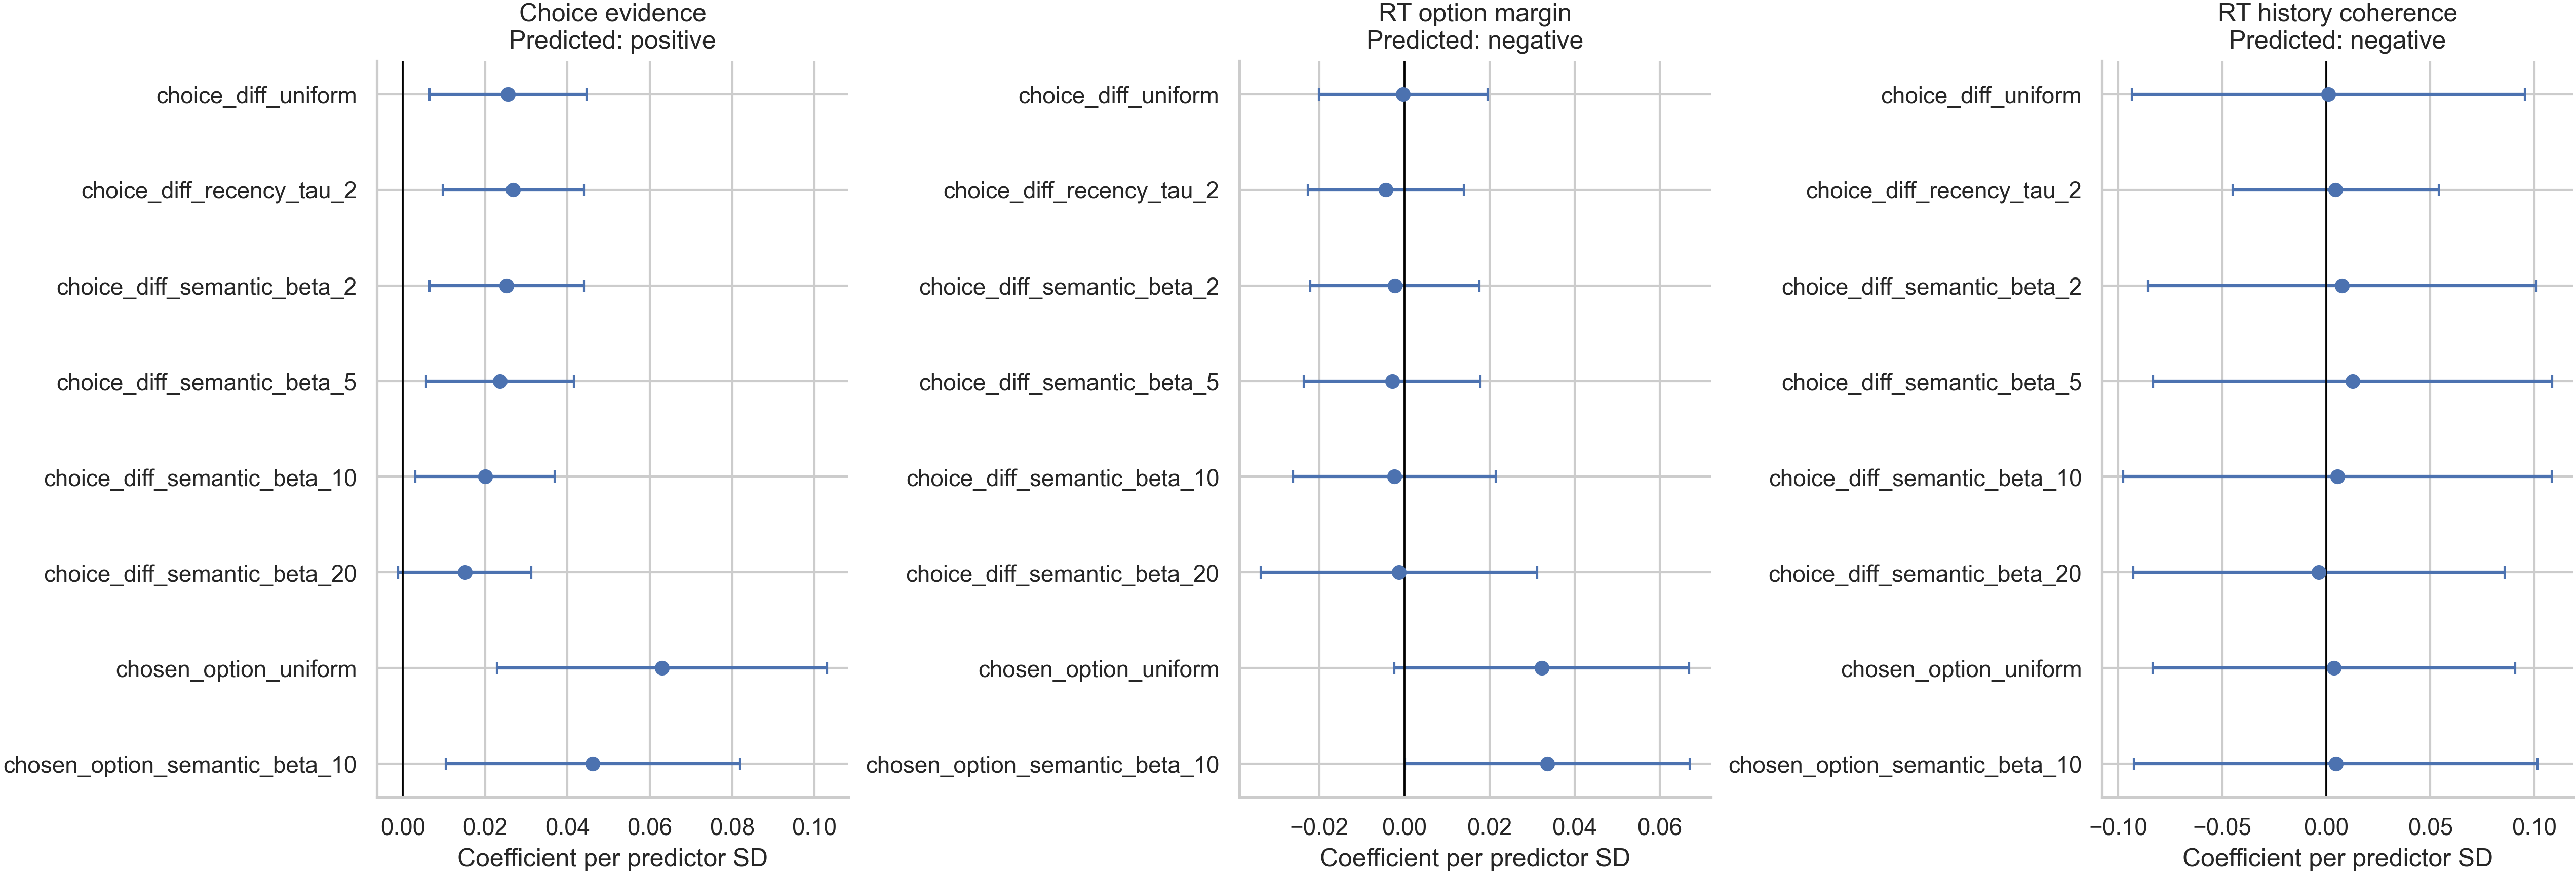

In [12]:
MODEL_ORDER = list(MODEL_SPECS)
plot_specs = [
    ("choice_opt1", "option_evidence", "Choice evidence", "positive"),
    ("log_rt", "option_margin", "RT option margin", "negative"),
    ("log_rt", "history_coherence", "RT history coherence", "negative"),
]

fig, axes = plt.subplots(1, 3, figsize=(17, 5.8), constrained_layout=True)
for axis, (outcome, predictor, title, predicted) in zip(axes, plot_specs):
    subset = (
        model_results[
            model_results["outcome"].eq(outcome)
            & model_results["predictor"].eq(predictor)
        ]
        .set_index("model").reindex(MODEL_ORDER).reset_index()
    )
    y = np.arange(len(subset))
    axis.errorbar(
        subset["beta"], y,
        xerr=np.vstack([
            subset["beta"] - subset["ci95_low"],
            subset["ci95_high"] - subset["beta"],
        ]),
        fmt="o", color="#4C72B0", capsize=3,
    )
    axis.axvline(0, color="black", linewidth=0.9)
    axis.set_yticks(y, subset["model"])
    axis.invert_yaxis()
    axis.set_title(f"{title}\nPredicted: {predicted}")
    axis.set_xlabel("Coefficient per predictor SD")
sns.despine(fig=fig)
plt.show()

## Does semantic weighting add beyond uniform history?

Separate positive coefficients do not establish an attention-specific
improvement. The decisive simple diagnostic includes uniform and semantic
choice-difference features together. A second joint diagnostic compares the
focal choice-difference value with the chosen-option value at the same beta.
An outcome-conditioned RT diagnostic is also shown: $G_t=(2y_t-1)D_t$. It
asks whether participants are faster when the retrieved state supports the
response ultimately made, but it is not prospective.

In [13]:
IDENTIFIERS = [
    "sub_id", "decision_num", "choice_opt1", "log_rt", "dimension",
    "character_role_num", "character_decision_num",
]
wide_features = None
for model_name, model_data in trial_features.groupby("model", sort=False):
    keep = model_data[IDENTIFIERS + [
        "option_evidence", "option_margin", "history_coherence",
    ]].copy()
    keep = keep.rename(columns={
        "option_evidence": f"evidence__{model_name}",
        "option_margin": f"margin__{model_name}",
        "history_coherence": f"coherence__{model_name}",
    })
    if wide_features is None:
        wide_features = keep
    else:
        wide_features = wide_features.merge(
            keep.drop(columns=[
                "choice_opt1", "log_rt", "dimension",
                "character_role_num", "character_decision_num",
            ]),
            on=["sub_id", "decision_num"],
            how="inner", validate="one_to_one",
        )

incremental_choice, _, _ = fit_two_way_fixed_effects(
    wide_features,
    "choice_opt1",
    [
        f"evidence__{PRIMARY_UNIFORM_MODEL}",
        f"evidence__{PRIMARY_SEMANTIC_MODEL}",
    ],
)
incremental_rt, _, _ = fit_two_way_fixed_effects(
    wide_features,
    "log_rt",
    [
        f"margin__{PRIMARY_UNIFORM_MODEL}",
        f"coherence__{PRIMARY_UNIFORM_MODEL}",
        f"margin__{PRIMARY_SEMANTIC_MODEL}",
        f"coherence__{PRIMARY_SEMANTIC_MODEL}",
    ],
)
value_comparison_choice, _, _ = fit_two_way_fixed_effects(
    wide_features,
    "choice_opt1",
    [
        f"evidence__{PRIMARY_SEMANTIC_MODEL}",
        f"evidence__{VALUE_COMPARISON_MODEL}",
    ],
)

wide_features[f"chosen_support__{PRIMARY_SEMANTIC_MODEL}"] = (
    (2 * wide_features["choice_opt1"] - 1)
    * wide_features[f"evidence__{PRIMARY_SEMANTIC_MODEL}"]
)
chosen_support_rt, _, _ = fit_two_way_fixed_effects(
    wide_features,
    "log_rt",
    [f"chosen_support__{PRIMARY_SEMANTIC_MODEL}"],
)

incremental_results = pd.concat(
    [incremental_choice, incremental_rt], ignore_index=True
)
print("Choice-difference uniform + semantic incremental models")
display(incremental_results[[
    "outcome", "predictor", "n", "beta", "se", "ci95_low",
    "ci95_high", "p", "r2",
]].round(4))
print("Choice-difference versus chosen-option values at semantic beta 10")
display(value_comparison_choice[[
    "outcome", "predictor", "n", "beta", "se", "ci95_low",
    "ci95_high", "p", "r2",
]].round(4))
print("Outcome-conditioned RT diagnostic")
display(chosen_support_rt[[
    "outcome", "predictor", "n", "beta", "se", "ci95_low",
    "ci95_high", "p", "r2",
]].round(4))

Choice-difference uniform + semantic incremental models


,outcome,predictor,n,beta,se,ci95_low,ci95_high,p,r2
0,choice_opt1,evidence__choice_diff_uniform,3569,0.0283,0.0127,0.0034,0.0533,0.0262,0.2400
1,choice_opt1,evidence__choice_diff_semantic_beta_10,3569,-0.0032,0.0083,-0.0194,0.0130,0.6972,0.2400
2,log_rt,margin__choice_diff_uniform,3569,0.0015,0.0148,-0.0275,0.0306,0.9185,0.5852
3,log_rt,coherence__choice_diff_uniform,3569,-0.0094,0.0708,-0.1480,0.1293,0.8948,0.5852
4,log_rt,margin__choice_diff_semantic_beta_10,3569,-0.0039,0.0180,-0.0393,0.0315,0.8292,0.5852
5,log_rt,coherence__choice_diff_semantic_beta_10,3569,0.0122,0.0794,-0.1434,0.1677,0.8783,0.5852


Choice-difference versus chosen-option values at semantic beta 10


,outcome,predictor,n,beta,se,ci95_low,ci95_high,p,r2
0,choice_opt1,evidence__choice_diff_semantic_beta_10,3569,0.0063,0.0316,-0.0556,0.0682,0.8419,0.2393
1,choice_opt1,evidence__chosen_option_semantic_beta_10,3569,0.0327,0.0698,-0.1041,0.1696,0.6393,0.2393


Outcome-conditioned RT diagnostic


,outcome,predictor,n,beta,se,ci95_low,ci95_high,p,r2
0,log_rt,chosen_support__choice_diff_semantic_beta_10,3569,-0.01,0.0069,-0.0236,0.0036,0.1501,0.5855


In [14]:
def result_row(table, outcome, predictor, model=None):
    selected = table[
        table["outcome"].eq(outcome)
        & table["predictor"].eq(predictor)
    ]
    if model is not None:
        selected = selected[selected["model"].eq(model)]
    return selected.iloc[0]


choice_primary = result_row(
    model_results, "choice_opt1", "option_evidence", PRIMARY_SEMANTIC_MODEL
)
margin_primary = result_row(
    model_results, "log_rt", "option_margin", PRIMARY_SEMANTIC_MODEL
)
coherence_primary = result_row(
    model_results, "log_rt", "history_coherence", PRIMARY_SEMANTIC_MODEL
)
semantic_increment = result_row(
    incremental_results,
    "choice_opt1",
    f"evidence__{PRIMARY_SEMANTIC_MODEL}",
)
uniform_increment = result_row(
    incremental_results,
    "choice_opt1",
    f"evidence__{PRIMARY_UNIFORM_MODEL}",
)
choice_diff_value_increment = result_row(
    value_comparison_choice,
    "choice_opt1",
    f"evidence__{PRIMARY_SEMANTIC_MODEL}",
)
chosen_option_value_increment = result_row(
    value_comparison_choice,
    "choice_opt1",
    f"evidence__{VALUE_COMPARISON_MODEL}",
)
chosen_rt = chosen_support_rt.iloc[0]

margin_result = (
    "longer rather than shorter"
    if margin_primary["beta"] > 0
    else "shorter"
)
summary = f"""
### Current result

- **Choice-difference value:** Under {PRIMARY_SEMANTIC_MODEL}, option evidence
  predicted
  choosing option 1 (beta = {choice_primary['beta']:.3f},
  p = {choice_primary['p']:.3f}).
- **Semantic increment:** With both histories present, uniform evidence was
  beta = {uniform_increment['beta']:.3f}, p = {uniform_increment['p']:.3f};
  semantic evidence was beta = {semantic_increment['beta']:.3f},
  p = {semantic_increment['p']:.3f}.
- **Value comparison:** With both beta-10 value definitions present, the
  choice-difference coefficient was beta =
  {choice_diff_value_increment['beta']:.3f},
  p = {choice_diff_value_increment['p']:.3f}; the chosen-option coefficient was
  beta = {chosen_option_value_increment['beta']:.3f},
  p = {chosen_option_value_increment['p']:.3f}.
- **Prospective RT prediction:** Larger semantic margin predicted
  {margin_result} RT (beta = {margin_primary['beta']:.3f},
  p = {margin_primary['p']:.3f}). Coherence was approximately null
  (beta = {coherence_primary['beta']:.3f}, p = {coherence_primary['p']:.3f}).
- **Outcome-conditioned diagnostic:** Support for the option eventually selected
  related to RT at beta = {chosen_rt['beta']:.3f}, p = {chosen_rt['p']:.3f}.

**Interpretation:** The focal state now has a relative-choice meaning: it is a
weighted mean of earlier chosen-minus-unchosen semantic directions. Evidence
for a history effect, a semantic-attention increment, and a value-definition
difference must be judged separately. None alone identifies attention as the
mechanism, and the prospective RT prediction remains a distinct test.
"""
display(Markdown(summary))


### Current result

- **Choice-difference value:** Under choice_diff_semantic_beta_10, option evidence
  predicted
  choosing option 1 (beta = 0.020,
  p = 0.021).
- **Semantic increment:** With both histories present, uniform evidence was
  beta = 0.028, p = 0.026;
  semantic evidence was beta = -0.003,
  p = 0.697.
- **Value comparison:** With both beta-10 value definitions present, the
  choice-difference coefficient was beta =
  0.006,
  p = 0.842; the chosen-option coefficient was
  beta = 0.033,
  p = 0.639.
- **Prospective RT prediction:** Larger semantic margin predicted
  shorter RT (beta = -0.002,
  p = 0.848). Coherence was approximately null
  (beta = 0.005, p = 0.918).
- **Outcome-conditioned diagnostic:** Support for the option eventually selected
  related to RT at beta = -0.010, p = 0.150.

**Interpretation:** The focal state now has a relative-choice meaning: it is a
weighted mean of earlier chosen-minus-unchosen semantic directions. Evidence
for a history effect, a semantic-attention increment, and a value-definition
difference must be judged separately. None alone identifies attention as the
mechanism, and the prospective RT prediction remains a distinct test.


## Boundaries and next falsification

- Query/key use the response choice-pair center, not the preceding scene.
- Historical values use stored `choice_diff`, but current evidence uses the
  task-fixed option-1-minus-option-2 axis; the current response never enters
  its own predictor.
- Uniform choice-difference history is the unweighted analogue of the stored
  `running_mean`; semantic attention changes only the retrieval weights.
- No beta should be selected because it fits these outcomes best.
- Item and participant fixed effects make the focal variation
  participant-specific.
- Stable relationship-specific choice policies can still generate sequential
  consistency. Shuffled key-value bindings, wrong-character histories, and a
  past-versus-future placebo are the next falsification tests.
- No neural data are used.